In [ ]:
# load dataset from shortcut in my Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# set path within my drive
dataset_path = "/content/drive/MyDrive/Dataset"

# define the classes available (folders)
classes = ["NORMAL", "DME", "DRUSEN"]

In [ ]:
import tensorflow as tf
# tensorflow documentation gives image training and augementation library
# https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator
# standard ImageDataGenerator setup from TensorFlow
# Goal: validate training and then validate test from that model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# folders for train and test data
train_dir = os.path.join(dataset_path, "train")
test_dir  = os.path.join(dataset_path, "test")

# settings for images
img_size = (128, 128)
batch_size = 32
classes = ["NORMAL", "DME", "DRUSEN"]

# augmentation randomizer limits (rescale is given in canvas)
train_gen_maker = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,             #80% train 20% validation
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

# test with no augmentation
test_gen_maker = ImageDataGenerator(
    rescale=1./255
)

# built in method that pulls each image, augments, labels, then feeds to trained
# as well as setting other parameters needed for this method from the IDG
train_gen = train_gen_maker.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=classes,
    class_mode="categorical",
    color_mode="rgb",
    subset="training",
    shuffle=True
)

# validation version of the generator above
val_gen = train_gen_maker.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=classes,
    class_mode="categorical",
    color_mode="rgb",
    subset="validation",
    shuffle=True
)

# testing version of the generator above (no augment)
test_gen = test_gen_maker.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=classes,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=False
)

Found 1815 images belonging to 3 classes.
Found 453 images belonging to 3 classes.
Found 963 images belonging to 3 classes.


In [ ]:
# from tensor flow document for layer additions (specifically keras)
from tensorflow.keras import layers

# load pretrained CNN to use as a feature extractor
# MobileNetV2 is the CNN trained by 'ImageNet'
# https://www.tensorflow.org/api_docs/python/tf/keras/applications/mobilenet_v2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_size[0], img_size[1], 3),  # 128x128 w/ 3 color channels
    include_top=False,  # allows my own classification
    weights="imagenet"  # learned weights from the pretrained model
)

# freeze pretrained layers so only the new layers train. wont change pretrained
base_model.trainable = False

# build the model from layer to layer
# 'Dense' is suggested neuron connection for simple models; connects every feat
model = tf.keras.Sequential([
    base_model,                            # insert pretrained
    layers.GlobalAveragePooling2D(),       # reduce features to a single vector
    layers.Dense(128, activation="relu"),  # af, covers nonlinear (from class)
    layers.Dropout(0.3), # drops 30% of neurons to reduce 'memorizing' (class)
    layers.Dense(len(classes), activation="softmax")  # final class probability
])

# show model success or failure w/ layers
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# compile the model (set how it learns and how its graded)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # optimizer from keras doc with small learning rate
    loss="categorical_crossentropy", # loss method defined by tensor flow
    metrics=["accuracy"]           # track accuracy during training (method)
)

In [ ]:
# callbacks (list) are for referencing previously viewed results while training
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",           # validation loss during training
        patience=5,                   # stop if doesn't improve for a few epochs
        restore_best_weights=True     # go back to the best model seen
    ),

    # for storing the previously best model
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",           # save the best version of the model
        monitor="val_loss",           # validation loss during training
        save_best_only=True           # only best model is useful
    )
]

In [ ]:
# train the model using the training data and validate
history = model.fit(
    train_gen,                 # use training data generator
    validation_data=val_gen,   # use validation data generator
    epochs=15,                 # max training passes if no early stop
    callbacks=callbacks        # use early stopping method
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 560s 10s/step - accuracy: 0.4398 - loss: 1.2801 - val_accuracy: 0.7263 - val_loss: 0.6994
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 396ms/step - accuracy: 0.6681 - loss: 0.7755 - val_accuracy: 0.7925 - val_loss: 0.5545
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 375ms/step - accuracy: 0.7079 - loss: 0.6677 - val_accuracy: 0.8168 - val_loss: 0.5014
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 390ms/step - accuracy: 0.7392 - loss: 0.5950 - val_accuracy: 0.8565 - val_loss: 0.4373
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 354ms/step - accuracy: 0.8142 - loss: 0.4798 - val_accuracy: 0.8168 - val_loss: 0.4524
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 387ms/step - accuracy: 0.8209 - loss: 0.4418 - val_accuracy: 0.8499 - val_loss: 0.4023
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 360ms/step - accuracy: 0.8368 - loss: 0.4361 - val_accuracy: 0.8300 - val_loss: 0.4207
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 373ms/step - accuracy: 0.8655 - loss: 0.3803 - val_accur

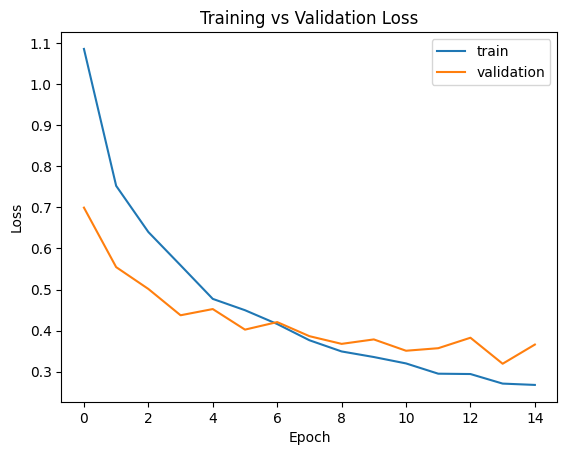

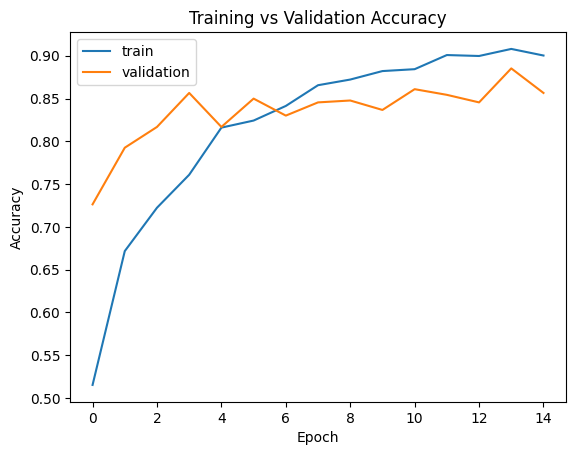

31/31 ━━━━━━━━━━━━━━━━━━━━ 352s 12s/step - accuracy: 0.9064 - loss: 0.2118
Test loss: 0.355124831199646
Test accuracy: 0.8452751636505127


In [ ]:
# for plotting my familiar looking graphs
import matplotlib.pyplot as plt

# plot loss over training
plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["train", "validation"])
plt.show()

# plot accuracy over training
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["train", "validation"])
plt.show()

# evaluate the trained model on the test data only (with built in method)
test_loss, test_accuracy = model.evaluate(test_gen)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

In [ ]:

import numpy as np

# best technique I could find for confusion matrices
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
from sklearn.metrics import confusion_matrix, classification_report

# get the true labels (folder names)
y_true = test_gen.classes

# pull model predictions for the test set
probs = model.predict(test_gen)     # runs predictions
y_pred = np.argmax(probs, axis=1)   # enumerates the classes for the cm

# confusion matrix make and print
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# more info from sklearn on performance (idk how to read this but figured it's useful)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step
Confusion Matrix:
 [[411  26   0]
 [ 38 267   0]
 [  3  82 136]]

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.91      0.94      0.92       437
         DME       0.71      0.88      0.79       305
      DRUSEN       1.00      0.62      0.76       221

    accuracy                           0.85       963
   macro avg       0.87      0.81      0.82       963
weighted avg       0.87      0.85      0.84       963

